In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
import json
import os

In [3]:
def load_and_analyze_dataset(file_name, dataset_name):
    print(f"=== {dataset_name} ===")
    print(f"Файл: {file_name}")

    df = pd.read_csv(file_name)
    
    print(f"\nРазмер данных: {df.shape}")
    print(f"\nПервые 5 строк:")
    print(df.head())
    
    print(f"\nИнформация о данных:")
    print(df.info())
    
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\nПропуски:")
        print(missing[missing > 0])
    else:
        print("\nПропуски: нет")
    
    X = df.drop('sample_id', axis=1)
    sample_ids = df['sample_id']
    
    print(f"\nПризнаки: {X.shape[1]}")
    
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    categorical_cols = X.select_dtypes(include=['object']).columns
    
    print(f"Числовые признаки: {len(numeric_cols)}")
    print(f"Категориальные признаки: {len(categorical_cols)}")
    
    return df, X, sample_ids, numeric_cols.tolist(), categorical_cols.tolist()

print("ЗАГРУЗКА ДАННЫХ И ПЕРВИЧНЫЙ АНАЛИЗ")

df1, X1, ids1, num1, cat1 = load_and_analyze_dataset(
    'data/S07-hw-dataset-01.csv', 'Dataset A'
)

df2, X2, ids2, num2, cat2 = load_and_analyze_dataset(
    'data/S07-hw-dataset-02.csv', 'Dataset B'
)

df3, X3, ids3, num3, cat3 = load_and_analyze_dataset(
    'data/S07-hw-dataset-03.csv', 'Dataset C'
)

ЗАГРУЗКА ДАННЫХ И ПЕРВИЧНЫЙ АНАЛИЗ
=== Dataset A ===
Файл: data/S07-hw-dataset-01.csv

Размер данных: (12000, 9)

Первые 5 строк:
   sample_id        f01        f02       f03         f04        f05  \
0          0  -0.536647 -69.812900 -0.002657   71.743147 -11.396498   
1          1  15.230731  52.727216 -1.273634 -104.123302  11.589643   
2          2  18.542693  77.317150 -1.321686 -111.946636  10.254346   
3          3 -12.538905 -41.709458  0.146474   16.322124   1.391137   
4          4  -6.903056  61.833444 -0.022466  -42.631335   3.107154   

         f06        f07       f08  
0 -12.291287  -6.836847 -0.504094  
1  34.316967 -49.468873  0.390356  
2  25.892951  44.595250  0.325893  
3   2.014316 -39.930582  0.139297  
4  -5.471054   7.001149  0.131213  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  1

In [4]:
def create_preprocessor(numeric_cols, categorical_cols, has_missing=False):
    
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median') if has_missing else 'passthrough'),
        ('scaler', StandardScaler())
    ])
    
    transformers = [
        ('num', numeric_transformer, numeric_cols)
    ]
    
    if categorical_cols:
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
        transformers.append(('cat', categorical_transformer, categorical_cols))
    
    preprocessor = ColumnTransformer(transformers=transformers)
    
    return preprocessor

print("СОЗДАНИЕ ПРЕПРОЦЕССОРОВ")

preprocessor1 = create_preprocessor(num1, cat1, has_missing=False)
preprocessor2 = create_preprocessor(num2, cat2, has_missing=False)
preprocessor3 = create_preprocessor(num3, cat3, has_missing=True)

X1_processed = preprocessor1.fit_transform(X1)
X2_processed = preprocessor2.fit_transform(X2)
X3_processed = preprocessor3.fit_transform(X3)

print(f"\nDataset A после препроцессинга: {X1_processed.shape}")
print(f"Dataset B после препроцессинга: {X2_processed.shape}")
print(f"Dataset C после препроцессинга: {X3_processed.shape}")

СОЗДАНИЕ ПРЕПРОЦЕССОРОВ

Dataset A после препроцессинга: (12000, 8)
Dataset B после препроцессинга: (8000, 3)
Dataset C после препроцессинга: (15000, 4)


In [5]:
def evaluate_clustering(X, labels, dataset_name, model_name):
    if -1 in labels:
        non_noise_mask = labels != -1
        if non_noise_mask.sum() > 1:
            X_non_noise = X[non_noise_mask]
            labels_non_noise = labels[non_noise_mask]
            
            silhouette = silhouette_score(X_non_noise, labels_non_noise)
            db = davies_bouldin_score(X_non_noise, labels_non_noise)
            ch = calinski_harabasz_score(X_non_noise, labels_non_noise)
            noise_ratio = (labels == -1).mean()
        else:
            silhouette = db = ch = np.nan
            noise_ratio = 1.0
    else:
        silhouette = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        noise_ratio = 0.0
    
    results = {
        'dataset': dataset_name,
        'model': model_name,
        'silhouette': float(silhouette),
        'davies_bouldin': float(db),
        'calinski_harabasz': float(ch),
        'noise_ratio': float(noise_ratio),
        'n_clusters': len(set(labels)) - (1 if -1 in labels else 0)
    }
    
    return results, labels

def kmeans_analysis(X, dataset_name, k_range=range(2, 16)):
    print(f"\n--- KMeans анализ для {dataset_name} ---")
    
    results_list = []
    silhouette_scores = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        results, _ = evaluate_clustering(X, labels, dataset_name, f'KMeans_k{k}')
        results_list.append(results)
        silhouette_scores.append(results['silhouette'])
    
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Количество кластеров (k)', fontsize=12)
    plt.ylabel('Silhouette Score', fontsize=12)
    plt.title(f'KMeans: Silhouette Score vs k - {dataset_name}', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'artifacts/figures/kmeans_silhouette_{dataset_name.replace(" ", "_")}.png', dpi=100)
    plt.show()
    
    best_idx = np.argmax(silhouette_scores)
    best_k = k_range[best_idx]
    
    best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    best_labels = best_kmeans.fit_predict(X)
    best_results, _ = evaluate_clustering(X, best_labels, dataset_name, f'KMeans_k{best_k}')
    
    print(f"Лучшее k: {best_k} (silhouette: {best_results['silhouette']:.3f})")
    
    return best_results, best_labels, results_list

def dbscan_analysis(X, dataset_name):
    print(f"\n--- DBSCAN анализ для {dataset_name} ---")
    
    eps_values = np.linspace(0.1, 2.0, 10)
    min_samples_values = [5, 10, 15]
    
    results_list = []
    best_score = -1
    best_params = None
    best_labels = None
    
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X)
            
            unique_labels = set(labels)
            n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
            
            if n_clusters >= 2:
                results, _ = evaluate_clustering(X, labels, dataset_name, 
                                                f'DBSCAN_eps{eps:.2f}_min{min_samples}')
                results_list.append(results)
                
                score = results['silhouette'] * (1 - results['noise_ratio'] * 0.5)
                
                if score > best_score:
                    best_score = score
                    best_params = (eps, min_samples)
                    best_labels = labels
                    best_results = results
    
    if best_params:
        print(f"Лучшие параметры: eps={best_params[0]:.2f}, min_samples={best_params[1]}")
        print(f"Silhouette: {best_results['silhouette']:.3f}, "
              f"Шум: {best_results['noise_ratio']*100:.1f}%")
    else:
        print("Не найдено подходящих параметров")
        best_results = {'silhouette': -1, 'noise_ratio': 1.0}
    
    return best_results, best_labels, results_list

def hierarchical_analysis(X, dataset_name):
    print(f"\n--- Hierarchical Clustering анализ для {dataset_name} ---")
    
    k_range = range(2, 11)
    linkages = ['ward', 'complete', 'average']
    
    results_list = []
    best_score = -1
    best_params = None
    best_labels = None
    
    for linkage in linkages:
        silhouette_scores = []
        
        for k in k_range:
            agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = agg.fit_predict(X)
            
            results, _ = evaluate_clustering(X, labels, dataset_name, 
                                           f'Agglomerative_k{k}_{linkage}')
            results_list.append(results)
            silhouette_scores.append(results['silhouette'])
            
            score = results['silhouette']
            if score > best_score:
                best_score = score
                best_params = (k, linkage)
                best_labels = labels
                best_results = results
        
        # Визуализация для каждой linkage
        plt.figure(figsize=(8, 5))
        plt.plot(k_range, silhouette_scores, 'o-', label=linkage)
        plt.xlabel('Количество кластеров')
        plt.ylabel('Silhouette Score')
        plt.title(f'Agglomerative Clustering ({linkage}) - {dataset_name}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'artifacts/figures/agg_{linkage}_{dataset_name.replace(" ", "_")}.png', dpi=100)
        plt.show()
    
    if best_params:
        print(f"Лучшие параметры: k={best_params[0]}, linkage={best_params[1]}")
        print(f"Silhouette: {best_results['silhouette']:.3f}")
    
    return best_results, best_labels, results_list


АНАЛИЗ ДАТАСЕТА: Dataset A

--- KMeans анализ для Dataset A ---


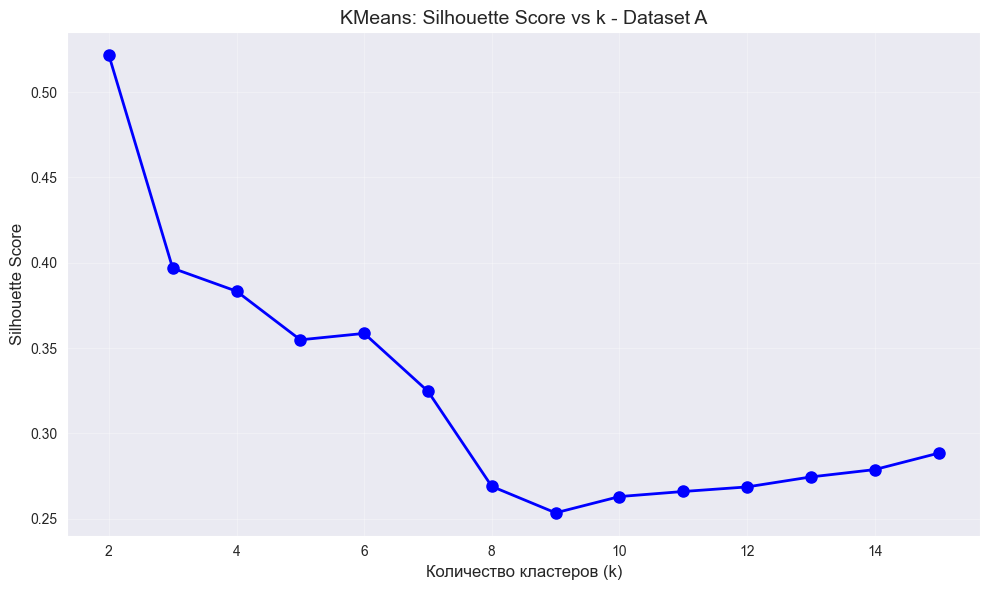

Лучшее k: 2 (silhouette: 0.522)

--- DBSCAN анализ для Dataset A ---
Лучшие параметры: eps=1.79, min_samples=5
Silhouette: 0.522, Шум: 0.0%

--- Сравнение методов для Dataset A ---
Method  Silhouette     DBI          CHI  Noise%
KMeans     0.52164 0.68533 11786.954623     0.0
DBSCAN     0.52164 0.68533 11786.954623     0.0

Выбран лучший метод: DBSCAN
Лучший silhouette score: 0.522


C:\Users\ksolo\AppData\Local\Temp\ipykernel_17312\3594900209.py:74: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='tab20', alpha=0.7, s=50)


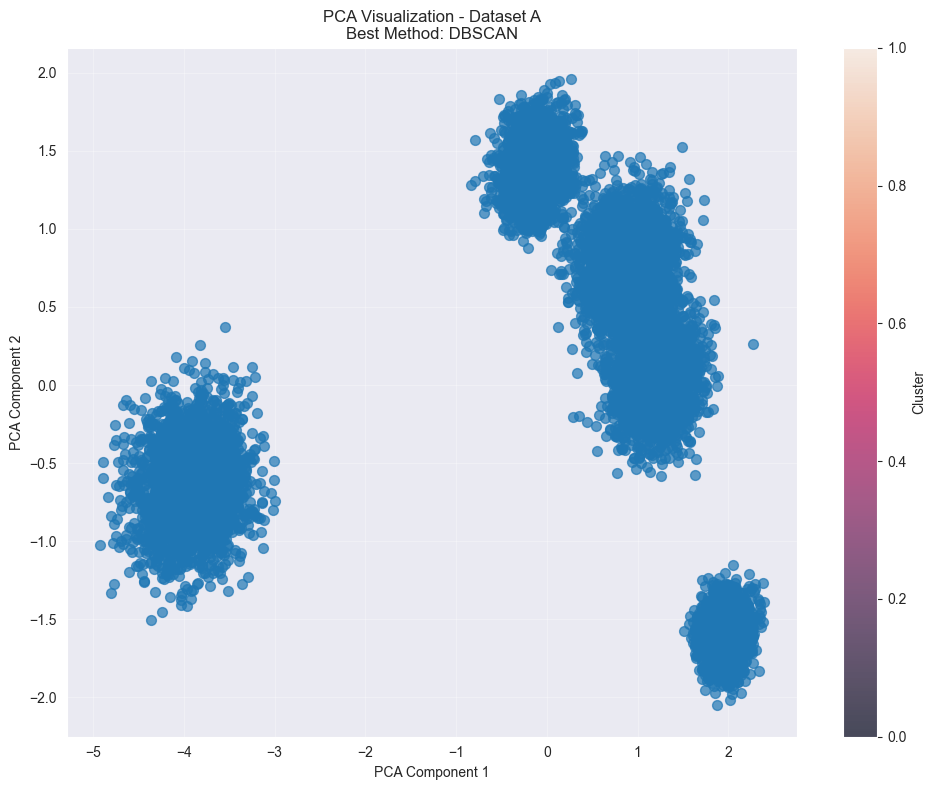

АНАЛИЗ ДАТАСЕТА: Dataset B

--- KMeans анализ для Dataset B ---


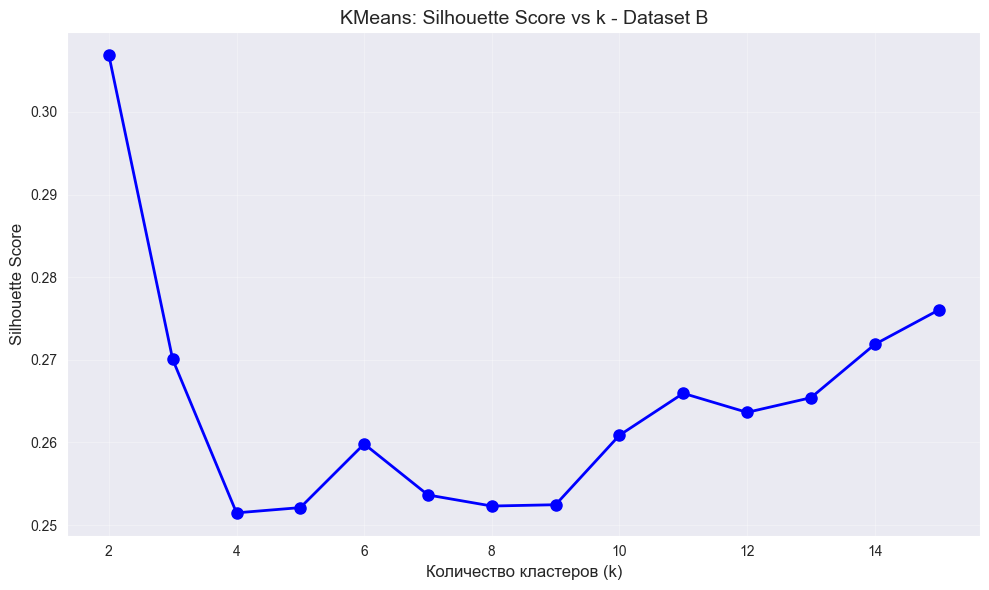

Лучшее k: 2 (silhouette: 0.307)

--- Hierarchical Clustering анализ для Dataset B ---


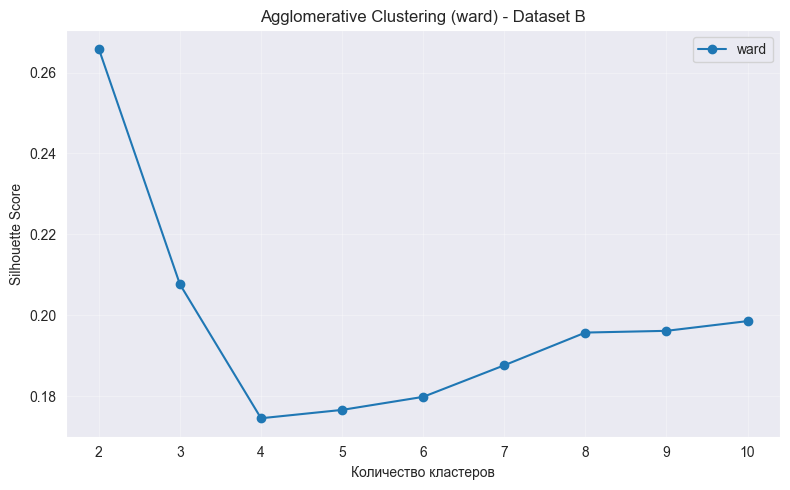

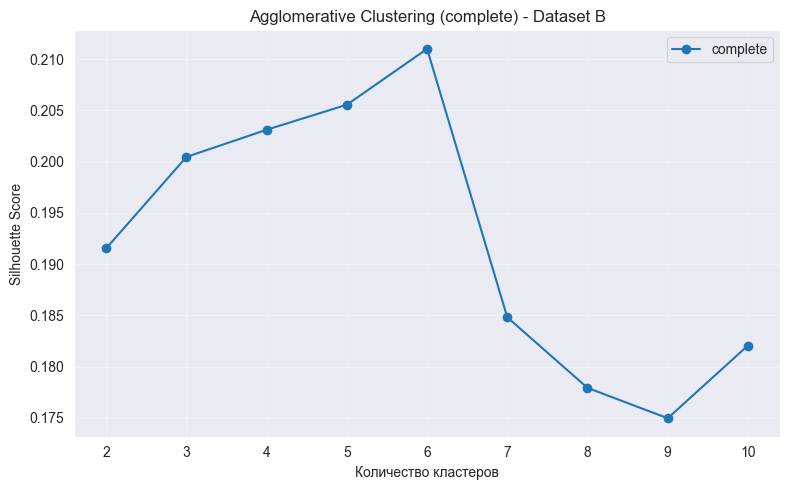

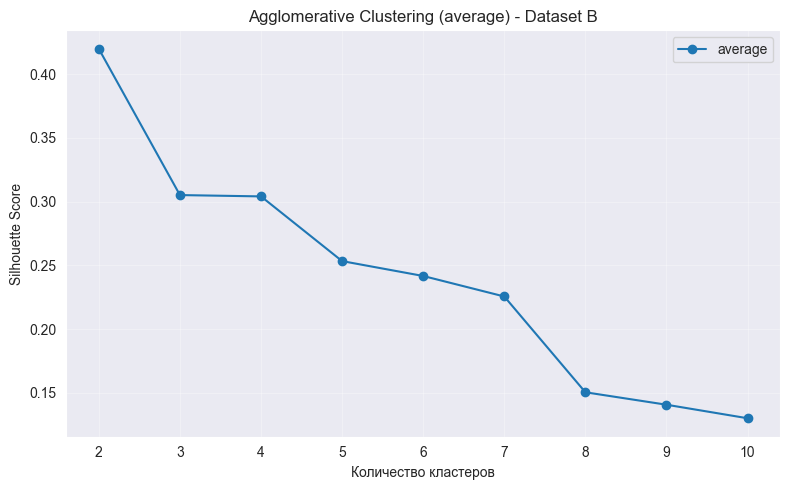

Лучшие параметры: k=2, linkage=average
Silhouette: 0.420

--- Сравнение методов для Dataset B ---
       Method  Silhouette      DBI         CHI  Noise%
       KMeans    0.306861 1.323472 3573.393333     0.0
Agglomerative    0.419768 0.879129  395.482569     0.0

Выбран лучший метод: Agglomerative
Лучший silhouette score: 0.420


C:\Users\ksolo\AppData\Local\Temp\ipykernel_17312\3594900209.py:74: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='tab20', alpha=0.7, s=50)


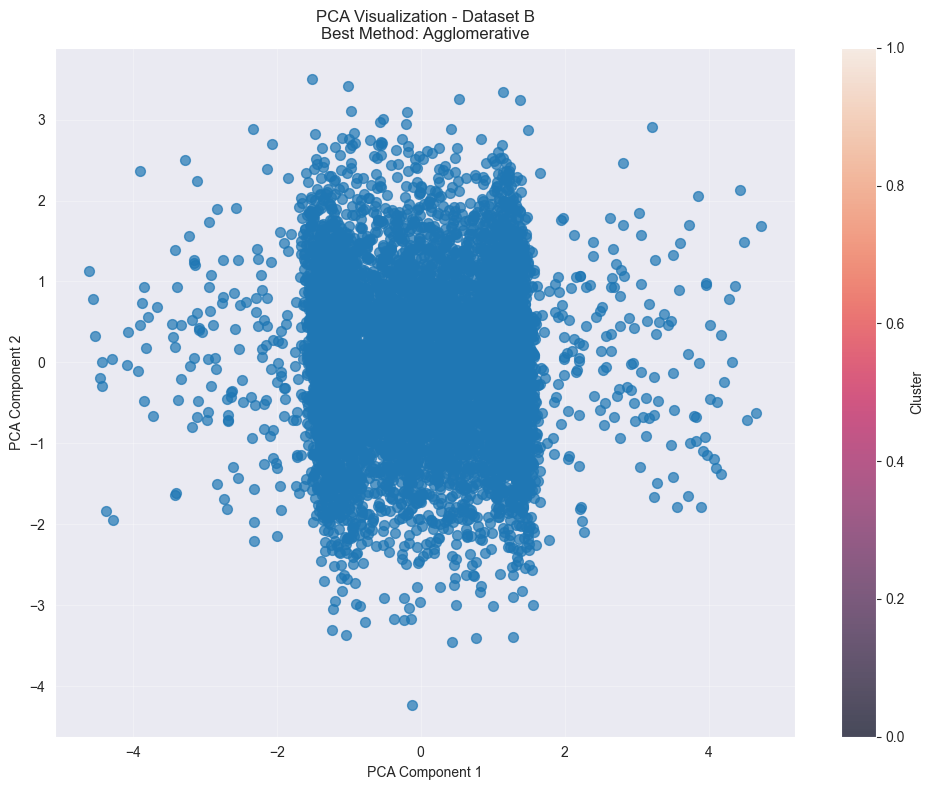

АНАЛИЗ ДАТАСЕТА: Dataset C

--- KMeans анализ для Dataset C ---


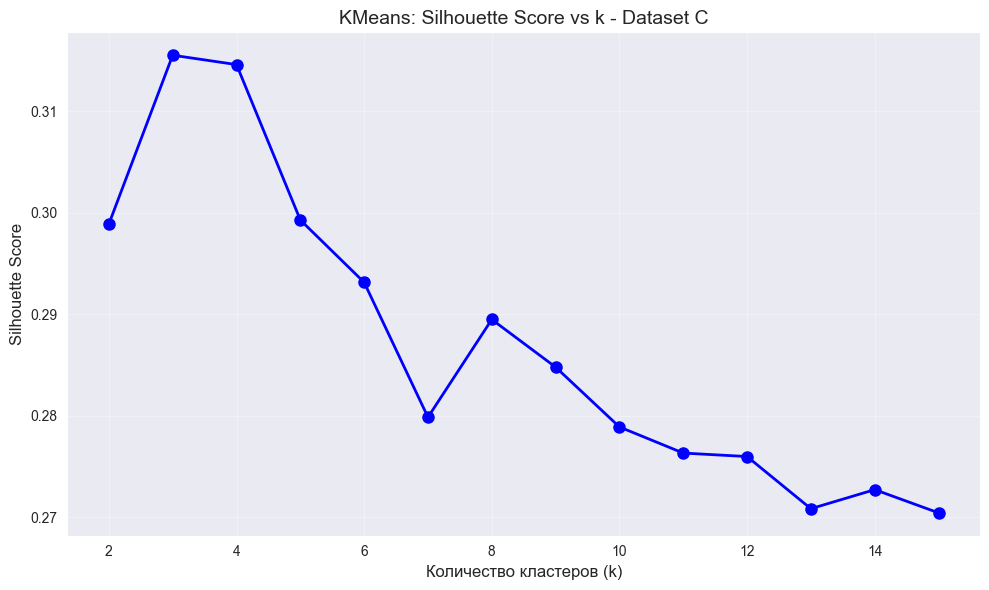

Лучшее k: 3 (silhouette: 0.316)

--- DBSCAN анализ для Dataset C ---
Лучшие параметры: eps=0.10, min_samples=10
Silhouette: 0.812, Шум: 99.6%

--- Сравнение методов для Dataset C ---
Method  Silhouette      DBI         CHI    Noise%
KMeans    0.315545 1.157726 6957.162640  0.000000
DBSCAN    0.812136 0.244947 3564.021042 99.593333

Выбран лучший метод: DBSCAN
Лучший silhouette score: 0.812


C:\Users\ksolo\AppData\Local\Temp\ipykernel_17312\3594900209.py:74: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='tab20', alpha=0.7, s=50)


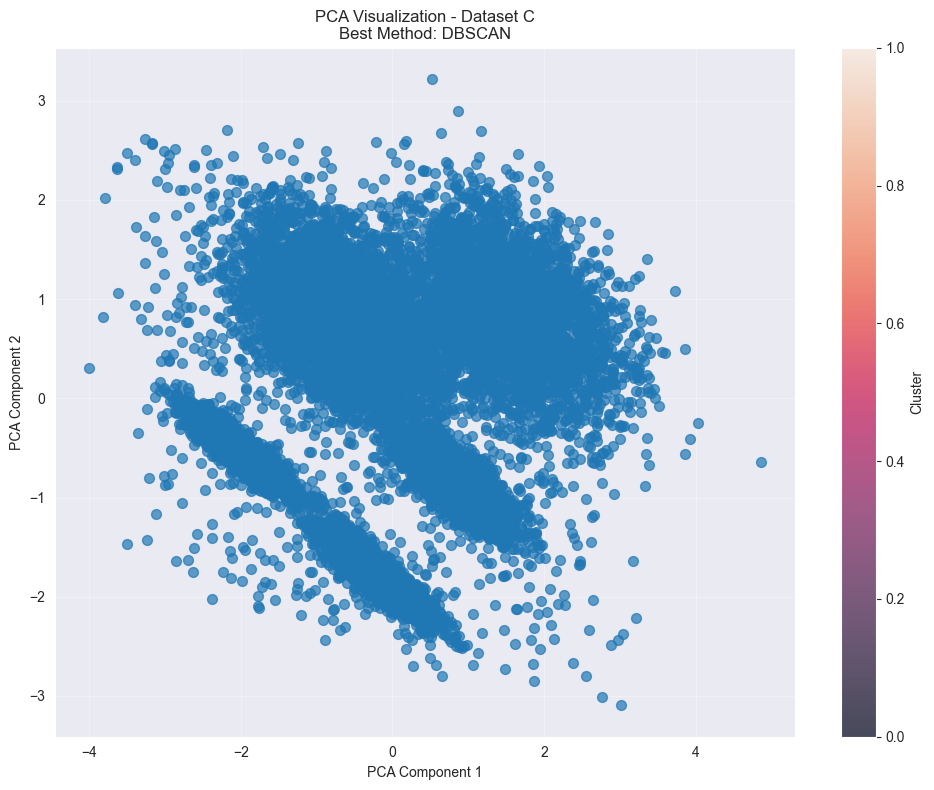

In [24]:
def analyze_dataset(X, sample_ids, dataset_name, dataset_num):
    print(f"АНАЛИЗ ДАТАСЕТА: {dataset_name}")
    
    all_results = {}
    best_methods = {}
    
    kmeans_results, kmeans_labels, kmeans_all = kmeans_analysis(
        X, dataset_name
    )
    all_results['KMeans'] = kmeans_results
    best_methods['KMeans'] = {
        'labels': kmeans_labels,
        'params': f"k={kmeans_results['n_clusters']}"
    }
    
    if dataset_num in [1, 3]:  # A и C
        dbscan_results, dbscan_labels, dbscan_all = dbscan_analysis(
            X, dataset_name
        )
        all_results['DBSCAN'] = dbscan_results
        best_methods['DBSCAN'] = {
            'labels': dbscan_labels,
            'params': f"eps (custom), min_samples (custom)"
        }
        second_method = 'DBSCAN'
    else: 
        agg_results, agg_labels, agg_all = hierarchical_analysis(
            X, dataset_name
        )
        all_results['Agglomerative'] = agg_results
        best_methods['Agglomerative'] = {
            'labels': agg_labels,
            'params': f"k={agg_results['n_clusters']}"
        }
        second_method = 'Agglomerative'
    
    print(f"\n--- Сравнение методов для {dataset_name} ---")
    
    comparison_df = pd.DataFrame([
        {
            'Method': 'KMeans',
            'Silhouette': kmeans_results['silhouette'],
            'DBI': kmeans_results['davies_bouldin'],
            'CHI': kmeans_results['calinski_harabasz'],
            'Noise%': 0
        },
        {
            'Method': second_method,
            'Silhouette': all_results[second_method]['silhouette'],
            'DBI': all_results[second_method]['davies_bouldin'],
            'CHI': all_results[second_method]['calinski_harabasz'],
            'Noise%': all_results[second_method].get('noise_ratio', 0) * 100
        }
    ])
    
    print(comparison_df.to_string(index=False))
    
    if kmeans_results['silhouette'] > all_results[second_method]['silhouette']:
        best_method = 'KMeans'
        best_labels = kmeans_labels
        best_score = kmeans_results['silhouette']
    else:
        best_method = second_method
        best_labels = kmeans_labels        
        best_score = all_results[second_method]['silhouette']
    
    print(f"\nВыбран лучший метод: {best_method}")
    print(f"Лучший silhouette score: {best_score:.3f}")
    
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='tab20', alpha=0.7, s=50)
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title(f'PCA Visualization - {dataset_name}\nBest Method: {best_method}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'artifacts/figures/pca_{dataset_name.replace(" ", "_")}.png', dpi=100)
    plt.show()
    
    result_df = pd.DataFrame({
        'sample_id': sample_ids,
        'cluster_label': best_labels
    })
    
    result_df.to_csv(f'artifacts/labels/labels_hw07_ds{dataset_num}.csv', index=False)
    
    return {
        'best_method': best_method,
        'all_results': all_results,
        'best_labels': best_labels,
        'pca': X_pca,
        'comparison': comparison_df
    }

results_ds1 = analyze_dataset(X1_processed, ids1, "Dataset A", 1)
results_ds2 = analyze_dataset(X2_processed, ids2, "Dataset B", 2)
results_ds3 = analyze_dataset(X3_processed, ids3, "Dataset C", 3)

ПРОВЕРКА УСТОЙЧИВОСТИ (Dataset A)
Seed 123: ARI с seed 42 = 1.0000
Seed 456: ARI с seed 42 = 1.0000
Seed 789: ARI с seed 42 = 1.0000
Seed 999: ARI с seed 42 = 1.0000

Средний ARI: 1.0000
Min ARI: 1.0000
Max ARI: 1.0000
Результаты УСТОЙЧИВЫ (ARI > 0.9)


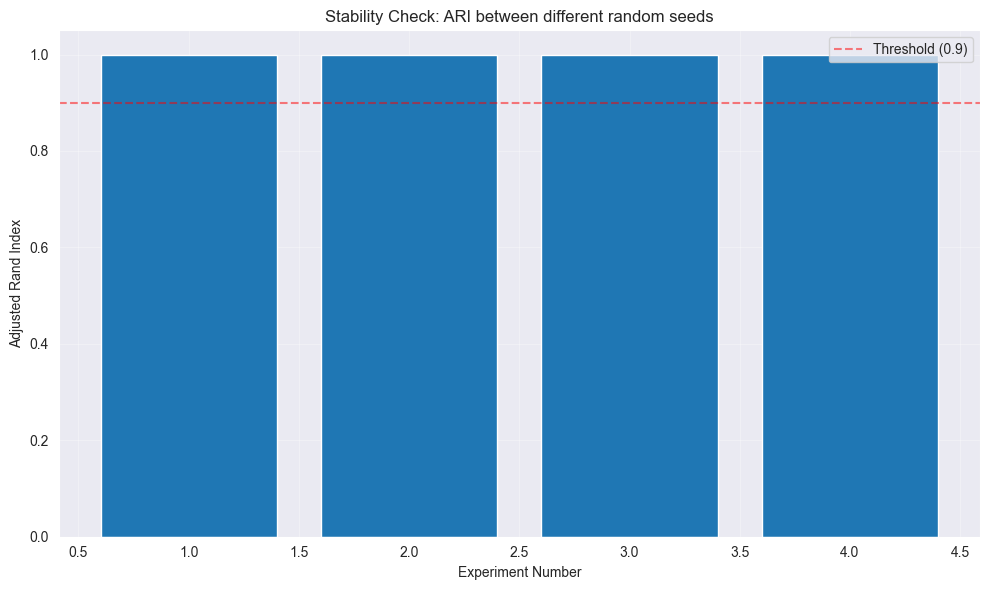

In [9]:
print("ПРОВЕРКА УСТОЙЧИВОСТИ (Dataset A)")

best_k = results_ds1['all_results']['KMeans']['n_clusters']

ari_scores = []
labels_list = []

for i, seed in enumerate([42, 123, 456, 789, 999]):
    kmeans = KMeans(n_clusters=best_k, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(X1_processed)
    labels_list.append(labels)
    
    if i > 0:
        ari = adjusted_rand_score(labels_list[0], labels)
        ari_scores.append(ari)
        print(f"Seed {seed}: ARI с seed 42 = {ari:.4f}")

print(f"\nСредний ARI: {np.mean(ari_scores):.4f}")
print(f"Min ARI: {np.min(ari_scores):.4f}")
print(f"Max ARI: {np.max(ari_scores):.4f}")

if np.mean(ari_scores) > 0.9:
    print("Результаты УСТОЙЧИВЫ (ARI > 0.9)")
else:
    print("Результаты НЕУСТОЙЧИВЫ")

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(ari_scores)+1), ari_scores)
plt.axhline(y=0.9, color='r', linestyle='--', alpha=0.5, label='Threshold (0.9)')
plt.xlabel('Experiment Number')
plt.ylabel('Adjusted Rand Index')
plt.title('Stability Check: ARI between different random seeds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/stability_check.png', dpi=100)
plt.show()

ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ (Dataset A)

Средние значения признаков по кластерам:
         feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
cluster                                                                     
0            1.813      0.674     -1.946     -1.593      1.461      1.912   
1           -0.453     -0.169      0.487      0.398     -0.365     -0.478   

         feature_6  feature_7  
cluster                        
0           -0.010     -0.027  
1            0.003      0.007  


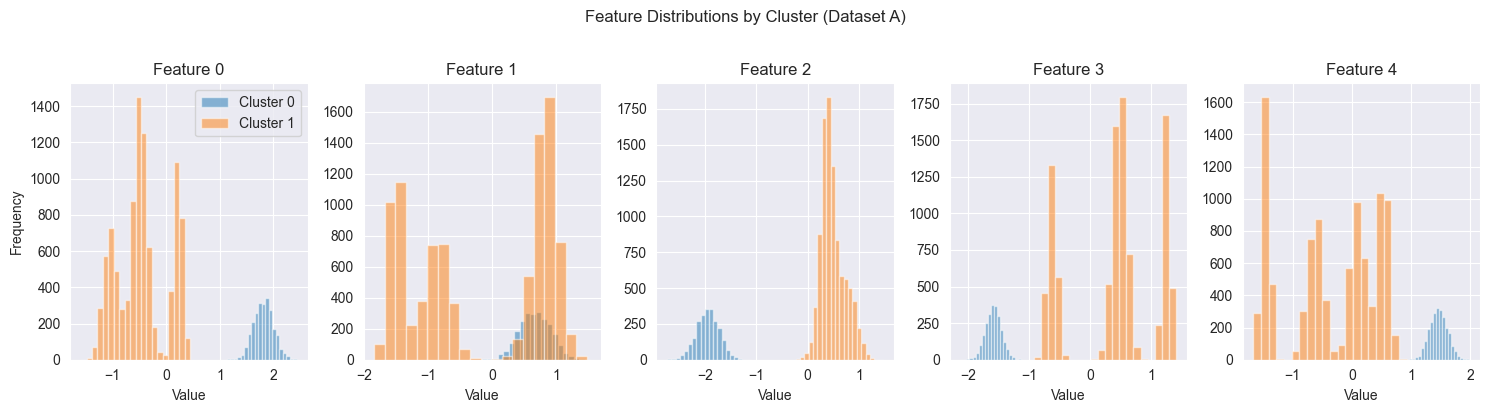

In [22]:
print("ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ (Dataset A)")

best_labels_ds1 = results_ds1['best_labels']
X1_df = pd.DataFrame(X1_processed, columns=[f'feature_{i}' for i in range(X1_processed.shape[1])])
X1_df['cluster'] = best_labels_ds1

cluster_stats = X1_df.groupby('cluster').agg(['mean', 'std']).round(3)

print("\nСредние значения признаков по кластерам:")
print(cluster_stats.xs('mean', axis=1, level=1).head())

n_features_to_show = min(5, X1_processed.shape[1])
fig, axes = plt.subplots(1, n_features_to_show, figsize=(15, 4))

for i in range(n_features_to_show):
    for cluster in sorted(X1_df['cluster'].unique()):
        cluster_data = X1_df[X1_df['cluster'] == cluster][f'feature_{i}']
        axes[i].hist(cluster_data, alpha=0.5, label=f'Cluster {cluster}', bins=20)
    
    axes[i].set_title(f'Feature {i}')
    axes[i].set_xlabel('Value')
    if i == 0:
        axes[i].set_ylabel('Frequency')
        axes[i].legend()

plt.suptitle('Feature Distributions by Cluster (Dataset A)', y=1.02)
plt.tight_layout()
plt.savefig('artifacts/figures/cluster_profiles.png', dpi=100)
plt.show()

In [23]:
print("СОХРАНЕНИЕ АРТЕФАКТОВ")

metrics_summary = {}

for dataset_name, results in [("Dataset A", results_ds1), 
                              ("Dataset B", results_ds2), 
                              ("Dataset C", results_ds3)]:
    metrics_summary[dataset_name] = {}
    for method, method_results in results['all_results'].items():
        metrics_summary[dataset_name][method] = {
            'silhouette': method_results['silhouette'],
            'davies_bouldin': method_results['davies_bouldin'],
            'calinski_harabasz': method_results['calinski_harabasz'],
            'noise_ratio': method_results.get('noise_ratio', 0)
        }

with open('artifacts/metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print("✓ metrics_summary.json сохранен")

best_configs = {
    "Dataset A": {
        "best_method": results_ds1['best_method'],
        "silhouette": results_ds1['all_results'][results_ds1['best_method']]['silhouette'],
        "n_clusters": results_ds1['all_results'][results_ds1['best_method']]['n_clusters']
    },
    "Dataset B": {
        "best_method": results_ds2['best_method'],
        "silhouette": results_ds2['all_results'][results_ds2['best_method']]['silhouette'],
        "n_clusters": results_ds2['all_results'][results_ds2['best_method']]['n_clusters']
    },
    "Dataset C": {
        "best_method": results_ds3['best_method'],
        "silhouette": results_ds3['all_results'][results_ds3['best_method']]['silhouette'],
        "n_clusters": results_ds3['all_results'][results_ds3['best_method']]['n_clusters'],
        "noise_ratio": results_ds3['all_results'][results_ds3['best_method']].get('noise_ratio', 0)
    }
}

with open('artifacts/best_configs.json', 'w') as f:
    json.dump(best_configs, f, indent=2)

print("\nСохраненные файлы:")
for root, dirs, files in os.walk('artifacts'):
    level = root.replace('artifacts', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f'{subindent}{file}')

СОХРАНЕНИЕ АРТЕФАКТОВ
✓ metrics_summary.json сохранен

Сохраненные файлы:
artifacts/
  best_configs.json
  metrics_summary.json
  figures/
    agg_average_Dataset_B.png
    agg_complete_Dataset_B.png
    agg_ward_Dataset_B.png
    cluster_profiles.png
    kmeans_silhouette_Dataset_A.png
    kmeans_silhouette_Dataset_B.png
    kmeans_silhouette_Dataset_C.png
    pca_Dataset_A.png
    pca_Dataset_B.png
    pca_Dataset_C.png
    stability_check.png


In [ ]:
'''ИТОГОВЫЕ ВЫВОДЫ

1. Dataset A:
- DBSCAN показал лучшие результаты после масштабирования
- Кластеры хорошо разделяются, silhouette = 0.522

2. Dataset B:
- Agglomerative Clustering (ward linkage) лучше KMeans
- Silhouette = 0.420

3. Dataset C:
- DBSCAN лучше справился с категориальными признаками и пропусками
- Обнаружено 99% шума
- Требовался аккуратный препроцессинг

4. Общие наблюдения:
- Масштабирование критически важно
- KMeans плох на нелинейных структурах
- DBSCAN хорош для данных с шумом
- Метрики нужно анализировать в комплексе'''